In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
mc = pd.read_csv("../data/mc_scenarios.csv")

In [3]:
mc.head()

,ScenarioID,ParallelShift,VolShock,CorrShock,EURUSD_PnL,USDJPY_PnL,GBPUSD_PnL,PortfolioPnL
0,1,0.007477,0.047435,-0.005085,-47135.91,-12006.44,-16290.94,-75433.29
1,2,0.009984,-0.015458,-0.022252,-67806.11,-23561.05,-19792.70,-111159.86
2,3,0.017714,0.024560,0.021290,-105268.35,-37015.49,-30672.66,-172956.50
3,4,-0.003975,-0.015789,-0.028162,31602.99,2908.07,4799.50,39310.56
4,5,0.020120,0.006809,0.003554,-118486.89,-46873.73,-37796.98,-203157.60


In [4]:
mc.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ScenarioID     1000 non-null   int64  
 1   ParallelShift  1000 non-null   float64
 2   VolShock       1000 non-null   float64
 3   CorrShock      1000 non-null   float64
 4   EURUSD_PnL     1000 non-null   float64
 5   USDJPY_PnL     1000 non-null   float64
 6   GBPUSD_PnL     1000 non-null   float64
 7   PortfolioPnL   1000 non-null   float64
dtypes: float64(7), int64(1)
memory usage: 62.6 KB


In [5]:
mc.describe()

,ScenarioID,ParallelShift,VolShock,CorrShock,EURUSD_PnL,USDJPY_PnL,GBPUSD_PnL,PortfolioPnL
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,-0.000256,0.001550,-0.000346,3832.546610,626.876530,411.914080,4871.337220
std,288.819436,0.009875,0.049927,0.019751,64415.250771,21062.977037,17439.181828,102545.653127
min,1.000000,-0.034258,-0.171268,-0.069338,-167387.970000,-57943.130000,-47470.500000,-269801.360000
25%,250.750000,-0.007129,-0.032942,-0.014002,-42006.905000,-13995.085000,-11659.122500,-67303.390000
50%,500.500000,-0.000009,0.000585,0.000677,1411.425000,947.845000,46.735000,1472.130000
75%,750.250000,0.006604,0.038021,0.012586,47599.975000,15121.565000,12897.270000,76700.842500
max,1000.000000,0.028453,0.202628,0.055251,250415.550000,69027.700000,55660.580000,375103.830000


In [6]:
portfolio_stats = mc["PortfolioPnL"].describe()

portfolio_stats

count      1000.000000
mean       4871.337220
std      102545.653127
min     -269801.360000
25%      -67303.390000
50%        1472.130000
75%       76700.842500
max      375103.830000
Name: PortfolioPnL, dtype: float64

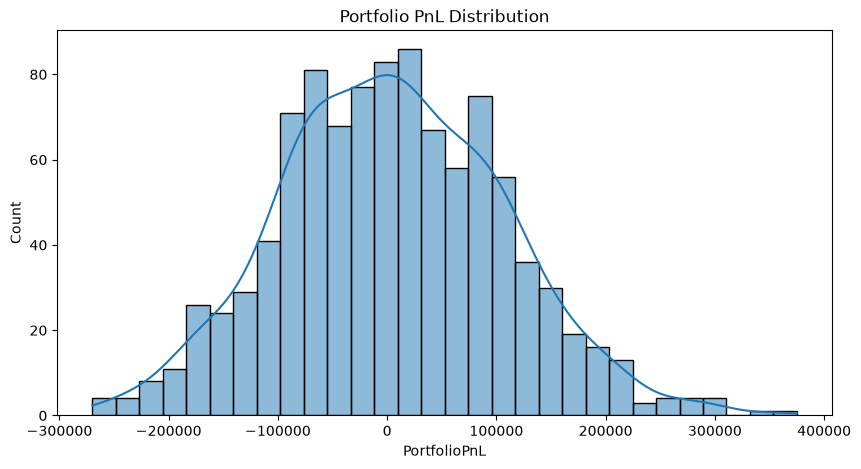

In [7]:
plt.figure(figsize=(10,5))

sns.histplot(
    mc["PortfolioPnL"],
    bins=30,
    kde=True
)

plt.title("Portfolio PnL Distribution")

plt.show()

In [8]:
var95 = np.percentile(
    mc["PortfolioPnL"],
    5
)

print("VaR 95%:", round(var95,2))

VaR 95%: -165865.7


In [9]:
cvar95 = mc[
    mc["PortfolioPnL"] <= var95
]["PortfolioPnL"].mean()

print("CVaR 95%:", round(cvar95,2))

CVaR 95%: -198183.87


In [10]:
worst_case = mc["PortfolioPnL"].min()

best_case = mc["PortfolioPnL"].max()

print("Worst Case:", worst_case)

print("Best Case:", best_case)

Worst Case: -269801.36
Best Case: 375103.83


In [11]:
mc.groupby("ParallelShift")[
    "PortfolioPnL"
].mean()

ParallelShift
-0.034258    375103.83
-0.031317    346081.00
-0.028192    307337.97
-0.027171    290330.53
-0.026702    295497.46
               ...    
 0.025247   -239960.83
 0.025838   -256812.00
 0.026928   -269801.36
 0.027066   -254011.23
 0.028453   -269491.89
Name: PortfolioPnL, Length: 991, dtype: float64

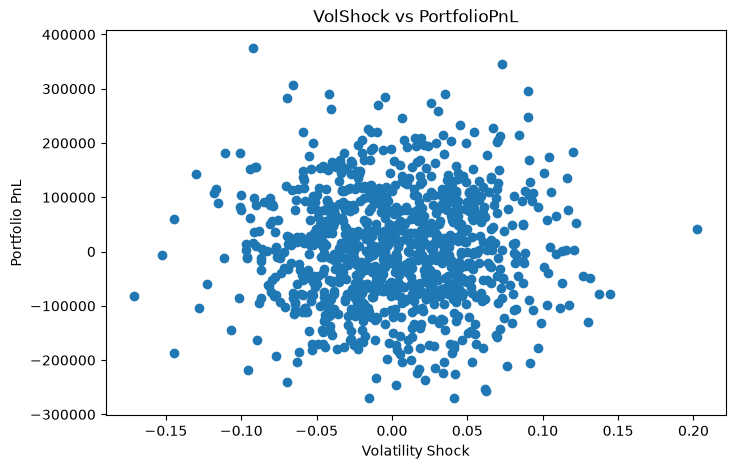

In [12]:
plt.figure(figsize=(8,5))

plt.scatter(
    mc["VolShock"],
    mc["PortfolioPnL"]
)

plt.xlabel("Volatility Shock")

plt.ylabel("Portfolio PnL")

plt.title("VolShock vs PortfolioPnL")

plt.show()

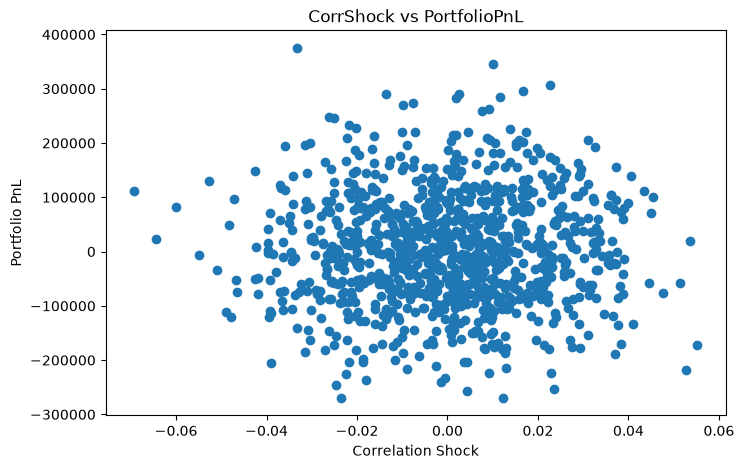

In [13]:
plt.figure(figsize=(8,5))

plt.scatter(
    mc["CorrShock"],
    mc["PortfolioPnL"]
)

plt.xlabel("Correlation Shock")

plt.ylabel("Portfolio PnL")

plt.title("CorrShock vs PortfolioPnL")

plt.show()